# Coursework Template

## Setup

**Dependencies and imports**

This can take a minute...

In [1]:
# !pip install swig
# !pip install rldurham
#!pip install --upgrade rldurham

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # disable CUDA (better on Colab/NCC: choose an environment without GPU)
import torch
import rldurham as rld

In [3]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import collections, random

# TQC Implementation

This implementation combines three main ideas:

- Kuznetsov et al. (2020), Truncated Quantile Critics (TQC): uses an ensemble of distributional critics and truncates the highest target quantiles to reduce overestimation bias in continuous control.
- Haarnoja et al. (2018), Soft Actor-Critic (SAC): provides the stochastic squashed-Gaussian actor, entropy-regularised objective, and automatic temperature tuning.
- Dabney et al. (2018), quantile regression for distributional RL: provides the quantile critic training objective used to model a return distribution rather than a single scalar Q-value.

The implementation is not a direct copy of any specific paper: it adapts these ideas to the Walker task and extends them with observation normalisation, critic LayerNorm.

In [4]:
# ─────────────────────────────────────────────
# Replay Buffer
# ─────────────────────────────────────────────
# stores transitions and reuses them across many updates,
# improves sample efficiency + reduces the strong temporal correlations that would arise if we learned only from consecutive on-policy samples.
# idea underpins modern off-policy deep RL methods such as DQN + SAC.
# Reference: Mnih et al. (2015), Human-level control through deep reinforcement learning.

class ReplayBuffer:
    """Fixed-size replay buffer storing (s, a, r, s2, done)."""

    def __init__(self, capacity: int, obs_dim: int, act_dim: int):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0

        self.s  = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.a  = np.zeros((capacity, act_dim), dtype=np.float32)
        self.r  = np.zeros((capacity, 1),       dtype=np.float32)
        self.s2 = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.d  = np.zeros((capacity, 1),       dtype=np.float32)

    def push(self, s, a, r, s2, done):
        self.s[self.ptr]  = s
        self.a[self.ptr]  = a
        self.r[self.ptr]  = r
        self.s2[self.ptr] = s2
        self.d[self.ptr]  = float(done)

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.as_tensor(self.s[idx],  dtype=torch.float32),
            torch.as_tensor(self.a[idx],  dtype=torch.float32),
            torch.as_tensor(self.r[idx],  dtype=torch.float32),
            torch.as_tensor(self.s2[idx], dtype=torch.float32),
            torch.as_tensor(self.d[idx],  dtype=torch.float32),
        )

    def __len__(self):
        return self.size

In [5]:
# ─────────────────────────────────────────────
# Network Definitions
# ─────────────────────────────────────────────
# actor + critics are implemented as small MLPs
# uses low-dimensional vector observations rather than images.
# Hidden width controls representational capacity: wider networks can model more
# complex value functions and policies, but they also train more slowly and can
# become less data-efficient if capacity is increased without enough experience.

# Critic MLP uses LayerNorm to stabilise intermediate activations.
# This is particularly useful here because Q-values change scale substantially
# during training, so normalisation helps keep critic updates well-behaved.
# Reference: Ba et al. (2016), Layer Normalization.

# Hidden = 256/512, Width of each neural networl layer. 
# Bigger = more capacity to represent complex behaviours, but slower to train and needs more data to converge.
# If you change this, be sure to change this as well in the actor class
def mlp(in_dim: int, out_dim: int, hidden: int = 256):
    return nn.Sequential(
        nn.Linear(in_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(),
        nn.Linear(hidden, out_dim),
    )


class Actor(nn.Module):
    """
    SAC-style squashed Gaussian actor.
    Outputs tanh-squashed actions in [-1, 1] and log-prob with correction.
    """
    # SAC-style stochastic actor:
    # the policy predicts a Gaussian in pre-squash space, then applies tanh so
    # actions always satisfy the environment bounds [-1, 1].
    # This gives smooth stochastic exploration while keeping the policy valid.
    # Reference: Haarnoja et al. (2018), Soft Actor-Critic.

    LOG_STD_MIN = -5
    LOG_STD_MAX = 2

    def __init__(self, obs_dim: int, act_dim: int, hidden: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, act_dim)
        self.log_std_head = nn.Linear(hidden, act_dim)

    def forward(self, s):
        h = self.net(s)
        mu = self.mu_head(h)
        log_std = self.log_std_head(h).clamp(self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mu, log_std

    def sample(self, s):
        """
        Returns:
          a     : (B, act_dim) in [-1,1]
          logpi : (B, 1)
        """
        mu, log_std = self.forward(s)
        std = log_std.exp()
        dist = Normal(mu, std)

        # Reparameterised sample in pre-tanh space
        x = dist.rsample()
        a = torch.tanh(x)

        # Log prob with tanh correction
        # Tanh correction term from SAC (Haarnoja et al., 2018, Appendix C)
        logp = dist.log_prob(x).sum(dim=-1, keepdim=True)
        logp -= torch.log(1 - a.pow(2) + 1e-6).sum(dim=-1, keepdim=True)
        return a, logp

    @torch.no_grad()
    def act(self, s, deterministic=False):
        mu, log_std = self.forward(s)
        if deterministic:
            return torch.tanh(mu)
        std = log_std.exp()
        x = Normal(mu, std).sample()
        return torch.tanh(x)


class QuantileCritic(nn.Module):
    """
    Quantile critic: outputs N quantiles for Q(s,a).
    """
    # Distributional critic:
    # instead of predicting a single scalar Q(s,a), each critic predicts a set
    # of quantiles representing the return distribution. This gives TQC access
    # to richer uncertainty structure than a standard mean-value critic and is
    # what makes quantile truncation possible later in the target computation.
    # Reference: Dabney et al. (2018), Distributional RL with Quantile Regression.

    def __init__(self, obs_dim: int, act_dim: int, n_quantiles: int, hidden: int = 256):
        super().__init__()
        self.n_quantiles = n_quantiles
        self.net = mlp(obs_dim + act_dim, n_quantiles, hidden)

    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=-1))  # (B, Nq)

**Reinforcement learning agent**

Replace this with your own agent. Also see the SAC implementationi below for a starting point.

In [6]:
# Running observation normaliser:
# the Walker state vector contains features on very different scales, so online
# normalisation makes optimisation easier by keeping inputs closer to zero mean
# and unit variance throughout training. Unlike BatchNorm, this operates on the
# incoming environment observations directly rather than internal network layers.
# In experiments, this was one of the most important changes for stable learning.

class RunningNormalizer:
    def __init__(self, dim, epsilon=1e-8):
        self.mean = np.zeros(dim, dtype=np.float32)
        self.var  = np.ones(dim,  dtype=np.float32)
        self.count = 0
        self.epsilon = epsilon

    def update(self, x):
        self.count += 1
        alpha = 1.0 / self.count
        delta = x - self.mean
        self.mean += alpha * delta
        self.var   = (1 - alpha) * self.var + alpha * delta * (x - self.mean)

    def normalize(self, x):
        return (x - self.mean) / (np.sqrt(self.var) + self.epsilon)

In [7]:
# ─────────────────────────────────────────────
# TQC Agent
# ─────────────────────────────────────────────
# This agent implements Truncated Quantile Critics (TQC), which extends SAC by
# replacing scalar critics with an ensemble of distributional quantile critics.
# The key idea is to pool target quantiles across critics, sort them, and drop
# the most optimistic tail before forming the Bellman target. This directly
# reduces overestimation bias, which is a major failure mode in off-policy actor-
# critic methods when function approximation errors are repeatedly bootstrapped.
# Reference: Kuznetsov et al. (2020), TQC.

class Agent(nn.Module):
    """
    Vanilla TQC:
      - N critics, each outputs Nq quantiles
      - Target uses pooled quantiles from all target critics, sorted, top dropped
      - Critic loss uses quantile regression (Huber)
      - Actor + alpha same as SAC
    """

    # ---- Hyperparameters you can tune ----
    N_CRITICS    = 5            # How many times critic networks run in parallel. More critics = better Q-value estimates but slower per update. 
    N_QUANTILES  = 25           # each critic outputs 25 quantile estimates of Q-value instead of one. More quantiles = smoother distribution estimate.
    TOP_DROP_PER = 2 # was 4         # drop TOP_DROP_PER from each critic (total drop = N_CRITICS*TOP_DROP_PER)

    LR_ACTOR  = 3e-4      # how fast the policy updates
    LR_CRITIC = 3e-4  # how fast the Q-value estimator updates (should generally be equal to or slightly higher than than actor LR)
    LR_ALPHA  = 3e-4      # How fast the entropy temperature adapts (This we rarely need to change)

    GAMMA = 0.99      # discount factor, how much the future rewards matter vs immediate ones (dont change)
    TAU   = 0.005       # How slowly the target networks track the live networks (lower = more stable but slower, higher = faster adaptation but more instability)

    BUFFER_SIZE  = int(1e6) # how many transitions stored, no need to change
    BATCH_SIZE   = 256      # how many transitions are sampled per update. standard as it is.
    WARMUP_STEPS = 5_000     # random actions for first N real env steps

    UPDATES_PER_STEP = 2      # gradient updates per env step (once learning starts)
    POLICY_DELAY     = 2      # update actor/alpha every 2 critic updates (stabilises)

    HIDDEN = 256
    GRAD_CLIP = 1   # was 5.0        # set to None to disable # caps graident size to prevent exploding updates # 5 is "generous" apparently, the original 1.0 was more "conservative")

    def __init__(self, env):
        super().__init__()

        self.discrete_act, self.discrete_obs, self.act_dim, self.obs_dim = rld.env_info(env)
        assert not self.discrete_act, "TQC requires continuous action space."
        assert not self.discrete_obs, "This implementation assumes vector observations."

        # Networks
        self.actor = Actor(self.obs_dim, self.act_dim, self.HIDDEN)

        self.critics = nn.ModuleList([
            QuantileCritic(self.obs_dim, self.act_dim, self.N_QUANTILES, self.HIDDEN)
            for _ in range(self.N_CRITICS)
        ])
        self.critics_target = nn.ModuleList([
            QuantileCritic(self.obs_dim, self.act_dim, self.N_QUANTILES, self.HIDDEN)
            for _ in range(self.N_CRITICS)
        ])
        for c, ct in zip(self.critics, self.critics_target):
            ct.load_state_dict(c.state_dict())
            for p in ct.parameters():
                p.requires_grad = False

        # Entropy temperature
        self.target_entropy = -float(self.act_dim)
        self.log_alpha = torch.zeros(1, requires_grad=True)
        self.alpha = self.log_alpha.exp().item()

        # Optimisers
        self.actor_opt  = optim.Adam(self.actor.parameters(), lr=self.LR_ACTOR)
        self.critic_opt = optim.Adam([p for c in self.critics for p in c.parameters()], lr=self.LR_CRITIC)
        self.alpha_opt  = optim.Adam([self.log_alpha], lr=self.LR_ALPHA)

        # Replay buffer
        self.buffer = ReplayBuffer(self.BUFFER_SIZE, self.obs_dim, self.act_dim)

        # Quantile midpoints taus: (i+0.5)/N
        taus = (torch.arange(self.N_QUANTILES, dtype=torch.float32) + 0.5) / self.N_QUANTILES
        self.taus = taus.view(1, self.N_QUANTILES, 1)  # (1, Nq, 1)

        # Counters
        self.total_steps = 0       # real env steps stored
        self.episode_steps = 0     # steps in current episode
        self.total_updates = 0

        self.obs_normalizer = RunningNormalizer(self.obs_dim) # added?

    # --------------------------------------------------------
    # Template interface
    # --------------------------------------------------------

    def sample_action(self, s):
        self.obs_normalizer.update(np.array(s, dtype=np.float32))  # update stats always
    
        if self.total_steps < self.WARMUP_STEPS:
            return (torch.rand(self.act_dim) * 2 - 1)

        s_norm = torch.as_tensor(
            self.obs_normalizer.normalize(np.array(s, dtype=np.float32)),
            dtype=torch.float32
        ).unsqueeze(0)
        with torch.no_grad():
            a, _ = self.actor.sample(s_norm)  # use s_norm not s_t
        return a.squeeze(0)

    def put_data(self, s, a, r, s2, done):
        """
        Store the *correct* transition (s,a,r,s2,done).
        This fixes the misalignment bug in the old version.
        """
        a_np = a.detach().cpu().numpy().astype(np.float32) if isinstance(a, torch.Tensor) else np.array(a, dtype=np.float32)

        self.buffer.push(
            np.array(s, dtype=np.float32),
            a_np,
            float(r),
            np.array(s2, dtype=np.float32),
            float(done),
        )
        self.total_steps += 1
        self.episode_steps += 1

    def train(self):
        """
        Called once per episode by the template loop.
        We do UPDATES_PER_STEP * episode_steps gradient updates.
        """
        # Not enough data yet
        if self.total_steps < self.WARMUP_STEPS:
            self.episode_steps = 0
            return
        if len(self.buffer) < self.BATCH_SIZE:
            self.episode_steps = 0
            return

        n_updates = self.UPDATES_PER_STEP * self.episode_steps
        for _ in range(n_updates):
            self._update()

        self.episode_steps = 0

    # --------------------------------------------------------
    # Core update
    # --------------------------------------------------------

    def _update(self):
        s, a, r, s2, d = self.buffer.sample(self.BATCH_SIZE)

        s_np  = s.numpy()
        s2_np = s2.numpy()
        s_norm  = torch.as_tensor(
            self.obs_normalizer.normalize(s_np), dtype=torch.float32)
        s2_norm = torch.as_tensor(
            self.obs_normalizer.normalize(s2_np), dtype=torch.float32)
        
        # -------------------------
        # 1) Build truncated target quantiles
        # -------------------------
        # Truncated Quantile Critics (TQC)
        # Following Kuznetsov et al. (2020):
        #   - Pool quantiles from all critics
        #   - Sort
        #   - Drop highest quantiles to reduce overestimation bias
        
        with torch.no_grad():
            # Step 1 - use s2_norm
            a2, log_pi2 = self.actor.sample(s2_norm)
            z2 = torch.stack([ct(s2_norm, a2) for ct in self.critics_target], dim=1)

            z2 = z2.view(self.BATCH_SIZE, -1)  # (B, C*Nq)

            # Sort and drop the top tail (largest)
            total = self.N_CRITICS * self.N_QUANTILES
            total_drop = self.N_CRITICS * self.TOP_DROP_PER
            assert 0 <= total_drop < total

            z2_sorted, _ = torch.sort(z2, dim=1)               # ascending
            z2_trunc = z2_sorted[:, : total - total_drop]      # keep all remaining (B, Kt)

            # SAC-style entropy term shifts the whole distribution
            alpha = self.log_alpha.exp()
            target_z = z2_trunc - alpha * log_pi2              # (B, Kt)

            # Bellman backup distribution
            y = r + self.GAMMA * (1 - d) * target_z            # (B, Kt)

        # -------------------------
        # 2) Critic update (quantile regression)
        # -------------------------
        # Quantile regression loss (Huber) as in QR-DQN (Dabney et al., 2018)
        # Weighting term |tau - I[delta < 0]|
        
        critic_loss = 0.0
        for c in self.critics:
            z = c(s_norm, a)  # (B, Nq) also using s_norm

            # Pairwise TD errors: (B, Nq, Kt)
            z_i = z.unsqueeze(2)          # (B, Nq, 1)
            y_j = y.unsqueeze(1)          # (B, 1,  Kt)
            td = y_j - z_i

            # Huber on td error (manual, avoids PyTorch broadcast warning)
            abs_td = td.abs()
            delta = 1.0
            huber = torch.where(
                abs_td <= delta,
                0.5 * td.pow(2),
                delta * (abs_td - 0.5 * delta)
            )  # (B, Nq, Kt)

            # Quantile weights: |tau - I[td<0]|
            weight = torch.abs(self.taus - (td.detach() < 0).float())    # (B,Nq,Kt)

            # Mean over target samples, sum over quantiles, mean over batch
            qloss = (weight * huber).mean(dim=2).sum(dim=1).mean()
            critic_loss = critic_loss + qloss

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()
        if self.GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_([p for c in self.critics for p in c.parameters()], self.GRAD_CLIP)
        self.critic_opt.step()

        # -------------------------
        # 3) Delayed actor + alpha updates
        # -------------------------
        # Conservative actor objective:
        # Instead of averaging over critics, we take min over critics
        # (similar in spirit to TD3/SAC twin-critic minimisation)
        # Improves stability by preventing exploitation of optimistic critics.
        
        if (self.total_updates % self.POLICY_DELAY) == 0:
            a_new, log_pi = self.actor.sample(s_norm)

            # Use mean over critics and quantiles as scalar objective
            z_new = torch.stack([c(s_norm, a_new) for c in self.critics], dim=1)
            q_mean = z_new.mean(dim=(1, 2), keepdim=True)                    # (B,1)

            alpha = self.log_alpha.exp()
            actor_loss = (alpha * log_pi - q_mean).mean()

            self.actor_opt.zero_grad(set_to_none=True)
            actor_loss.backward()
            if self.GRAD_CLIP is not None:
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), self.GRAD_CLIP)
            self.actor_opt.step()

            # Temperature update
            # Entropy regularisation with automatic temperature tuning
            # Soft Actor-Critic (Haarnoja et al., 2018)
            alpha_loss = -(self.log_alpha * (log_pi.detach() + self.target_entropy)).mean()
            self.alpha_opt.zero_grad(set_to_none=True)
            alpha_loss.backward()
            self.alpha_opt.step()

            self.alpha = self.log_alpha.exp().item()

        # -------------------------
        # 4) Soft update targets
        # -------------------------
        # Polyak averaging (soft target updates)
        # Common in DDPG / TD3 / SAC
        with torch.no_grad():
            for c, ct in zip(self.critics, self.critics_target):
                for p, pt in zip(c.parameters(), ct.parameters()):
                    pt.data.mul_(1 - self.TAU)
                    pt.data.add_(self.TAU * p.data)

        self.total_updates += 1


## Training

**Prepare the environment and wrap it to capture statistics, logs, and videos**

The device is: cpu (as recommended)
actions are continuous with 4 dimensions/#actions
observations are continuous with 24 dimensions/#observations
maximum timesteps is: 2000


/opt/anaconda3/envs/ReinforcementLearningCoursework/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


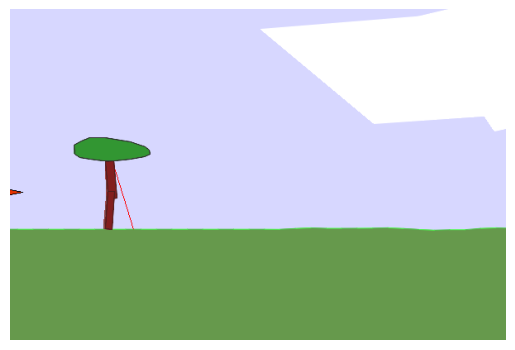

In [8]:
env = rld.make("rldurham/Walker", render_mode="rgb_array")
# env = rld.make("rldurham/Walker", render_mode="rgb_array", hardcore=True) # only attempt this when your agent has solved the non-hardcore version

# get statistics, logs, and videos
env = rld.Recorder(
    env,
    smoothing=10,                       # track rolling averages (useful for plotting)
    video=True,                         # enable recording videos
    video_folder="Easy_TQC_10/videos",              # folder for videos
    video_prefix="hqcb32-agent-video",  # prefix for videos (replace xxxx00 with your username)
    logs=True,                          # keep logs
)

# training on CPU recommended
rld.check_device()

# environment info
rld.env_info(env, print_out=True)

# render start image (reset just to render image)
env.reset(seed=42)
rld.render(env)

**Collect episodes and train the agent**

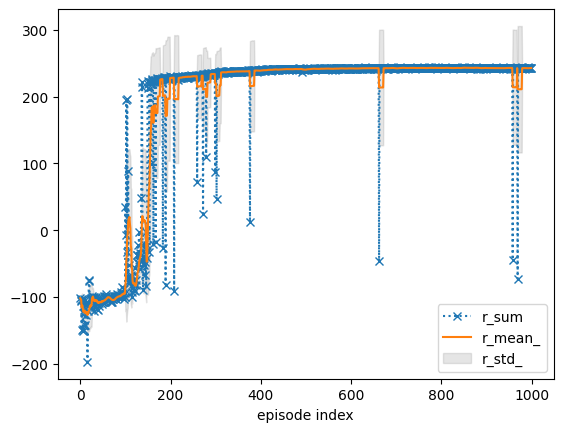

In [9]:
# in the submission please use seed_everything with seed 42 for verification
seed, observation, info = rld.seed_everything(42, env)

# initialise agent
agent = Agent(env)
max_episodes = 1000

# track statistics for plotting
tracker = rld.InfoTracker()

# switch video recording off (only switch on every x episodes as this is slow)
env.video = False

# training procedure
for episode in range(max_episodes):
    
    # recording statistics and video can be switched on and off (video recording is slow!)
    env.info = True                 # usually tracking every episode is fine
    env.video = episode % 25 == 0  # record videos every 25 episodes (set BEFORE calling reset!)

    # reset for new episode
    observation, info = env.reset()

    # run episode
    done = False
    while not done:
        
        s = observation
        
        # select the agent action
        action = agent.sample_action(observation)

        action_np = action.detach().cpu().numpy() if isinstance(action, torch.Tensor) else action

        # take action in the environment
        observation, reward, terminated, truncated, info = env.step(action)
        
        # check whether done
        done = terminated or truncated

        # remember
        agent.put_data(s, action, reward, observation, done)

    # train the agent after each episode
    agent.train()
            
    # track and plot statistics
    tracker.track(info)
    if (episode + 1) % 10 == 0:
        tracker.plot(r_mean_=True, r_std_=True, r_sum=dict(linestyle=':', marker='x'))

# don't forget to close environment (e.g. triggers last video save)
env.close()

# write log file (for coursework)
env.write_log(folder="Easy_TQC_10/logs", file="hqcb32-agent-log.txt")  # replace xxxx00 with your username

### References:
- Kuznetsov, A., et al. (2020). Controlling Overestimation Bias with Truncated Mixture of Continuous Distributional Quantile Critics. ICML.
- Haarnoja, T., et al. (2018). Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor. ICML.
- Fujimoto, S., et al. (2018). Addressing Function Approximation Error in Actor-Critic Methods. ICML.
- Dabney, W., et al. (2018). Distributional Reinforcement Learning with Quantile Regression. AAAI.
